In [ ]:
# Research Question: What is the relationship between female literacy, GDP per capita, fertility rate, female labor force participation across countries？
# Target Audience: Researchers and policymakers focused on gender, development, and demographics.

In [1]:
# Module 1: Importing Libraries
# ============================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pandas_datareader import wb

sns.set_style("whitegrid")
print("Libraries loaded")

Libraries loaded


In [2]:
# Module 2: Defining Indicators and Obtaining Data
# ============================================
indicators = {
    'SL.TLF.CACT.FE.ZS': 'female_lfp',      # Female labor force participation rate
    'SP.DYN.TFRT.IN': 'fertility',          # fertility rate
    'NY.GDP.PCAP.CD': 'gdp_per_capita',     # GDP per capita
    'SE.ADT.LITR.FE.ZS': 'female_literacy'  # female literacy rate
}

print("Downloading data from World Bank...")
df = wb.download(indicator=list(indicators.keys()), country='all', start=2000, end=2023)
df = df.reset_index()
df = df.rename(columns={'country': 'Country Name', 'year': 'Year'})
df['Year'] = df['Year'].astype(int)

/var/folders/7v/z1znj6ws4kx2fb2g90bdj3j00000gn/T/ipykernel_91111/3184469574.py:11: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df = wb.download(indicator=list(indicators.keys()), country='all', start=2000, end=2023)


In [5]:
# Rename indicator column
df.columns = ['Country Name', 'Year', 'female_lfp', 'fertility', 'gdp_per_capita', 'female_literacy']

print(f"Data downloaded: {df.shape}")
print(df.head())

Data downloaded: (6384, 6)
  Country Name  Year  female_lfp  fertility  gdp_per_capita  female_literacy
0  Afghanistan  2000      14.294      7.566      174.930991              NaN
1  Afghanistan  2001      14.196      7.453      138.706822              NaN
2  Afghanistan  2002      14.152      7.320      178.954088              NaN
3  Afghanistan  2003      14.154      7.174      198.871116              NaN
4  Afghanistan  2004      14.205      7.018      221.763654              NaN


In [6]:
# Module 3: Data Cleaning
# ============================================
print("\n=== Data Cleaning ===")


=== Data Cleaning ===


In [7]:
# Remove missing values (all four indicators must have data)
df = df.dropna(subset=['female_lfp', 'fertility', 'gdp_per_capita', 'female_literacy'])
print(f"After dropping NA: {df.shape}")


After dropping NA: (1804, 6)


In [8]:
# Filter outliers
df = df[(df['fertility'] >= 0.5) & (df['fertility'] <= 10)]
df = df[(df['female_lfp'] >= 0) & (df['female_lfp'] <= 100)]
df = df[(df['female_literacy'] >= 0) & (df['female_literacy'] <= 100)]
print(f"After filtering outliers: {df.shape}")


After filtering outliers: (1804, 6)


In [9]:
# Logarithmic transformation of GDP
df['log_gdp'] = np.log(df['gdp_per_capita'])

print(f"Final: {df['Country Name'].nunique()} countries, {df['Year'].nunique()} years")

Final: 188 countries, 24 years


In [10]:
# Module 4: Group by Income 
# ============================================
def get_income_group(gdp):
    if pd.isna(gdp):
        return 'Unknown'
    elif gdp < 1045:
        return 'Low Income'
    elif gdp < 4096:
        return 'Lower-Middle'
    elif gdp < 12695:
        return 'Upper-Middle'
    else:
        return 'High Income'

In [11]:
# Group by GDP of the latest year
latest_year = df['Year'].max()
gdp_latest = df[df['Year'] == latest_year][['Country Name', 'gdp_per_capita']].drop_duplicates()
gdp_latest['income_group'] = gdp_latest['gdp_per_capita'].apply(get_income_group)


In [12]:
# Merge grouping information
df = df.merge(gdp_latest[['Country Name', 'income_group']], on='Country Name', how='left')

print(f"\nIncome group distribution:")
print(df['income_group'].value_counts())


Income group distribution:
income_group
Upper-Middle    564
Lower-Middle    439
High Income     183
Low Income       48
Name: count, dtype: int64


In [13]:
# Module 5: Obtain the latest year's data for cross-sectional analysis
# ============================================
target_year = df['Year'].max()
df_analysis = df[df['Year'] == target_year].dropna(subset=['female_lfp', 'fertility', 'income_group', 'female_literacy'])
print(f"\nAnalysis year: {target_year}, Countries: {len(df_analysis)}")



Analysis year: 2023, Countries: 71


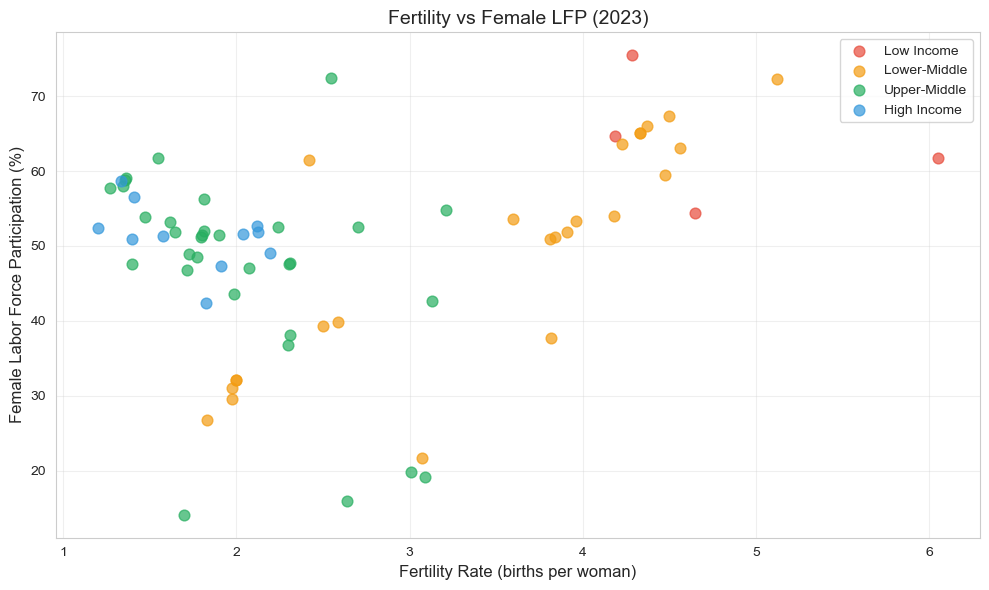

In [14]:
# Module 6: Visual Analysis
# ============================================

# color definition
colors = {'Low Income': '#E74C3C', 'Lower-Middle': '#F39C12', 
          'Upper-Middle': '#27AE60', 'High Income': '#3498DB'}

# Figure 1: Fertility Rate vs Female Labor Force Participation Rate
fig, ax = plt.subplots(figsize=(10, 6))
for group, color in colors.items():
    subset = df_analysis[df_analysis['income_group'] == group]
    ax.scatter(subset['fertility'], subset['female_lfp'], 
               c=color, label=group, alpha=0.7, s=60)
ax.set_xlabel('Fertility Rate (births per woman)', fontsize=12)
ax.set_ylabel('Female Labor Force Participation (%)', fontsize=12)
ax.set_title(f'Fertility vs Female LFP ({target_year})', fontsize=14)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('fertility_vs_lfp.png', dpi=150)
plt.show()

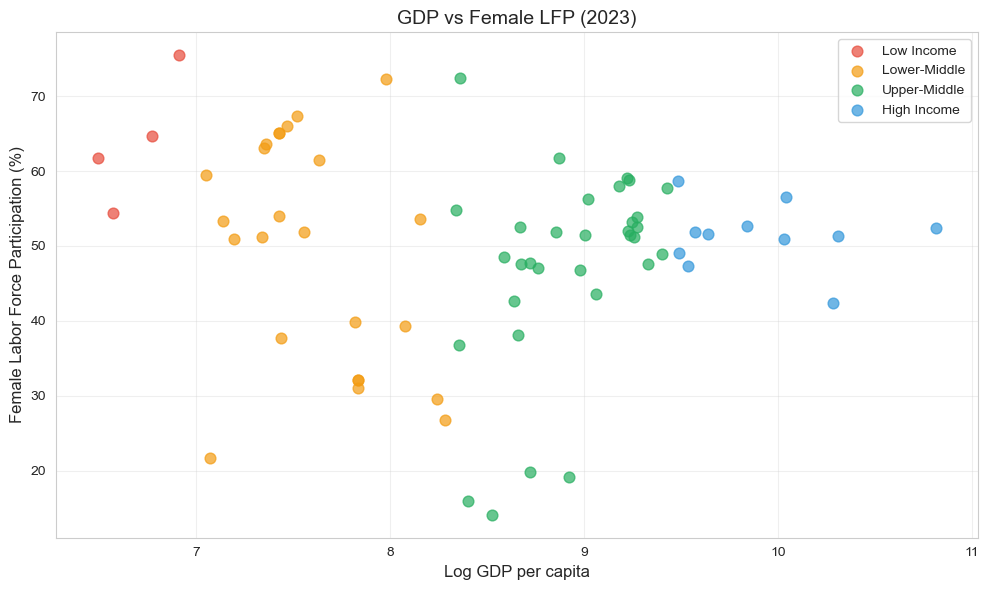

In [15]:
# Figure 2: GDP vs Female Labor Force Participation Rate
fig, ax = plt.subplots(figsize=(10, 6))
for group, color in colors.items():
    subset = df_analysis[df_analysis['income_group'] == group]
    ax.scatter(subset['log_gdp'], subset['female_lfp'], 
               c=color, label=group, alpha=0.7, s=60)
ax.set_xlabel('Log GDP per capita', fontsize=12)
ax.set_ylabel('Female Labor Force Participation (%)', fontsize=12)
ax.set_title(f'GDP vs Female LFP ({target_year})', fontsize=14)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('gdp_vs_lfp.png', dpi=150)
plt.show()


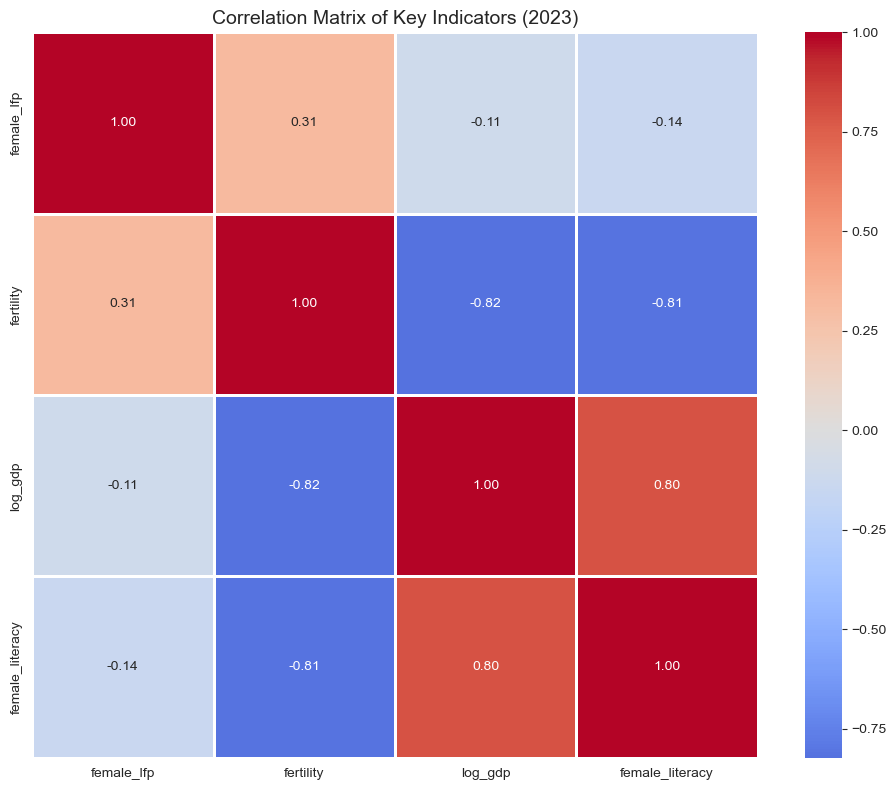

In [16]:
# Figure 3: Correlation heatmap 
fig, ax = plt.subplots(figsize=(10, 8))
corr_cols = ['female_lfp', 'fertility', 'log_gdp', 'female_literacy']
corr_matrix = df_analysis[corr_cols].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0,
            square=True, linewidths=1, ax=ax, fmt='.2f')
ax.set_title('Correlation Matrix of Key Indicators (2023)', fontsize=14)
plt.tight_layout()
plt.savefig('correlation_matrix.png', dpi=150)
plt.show()

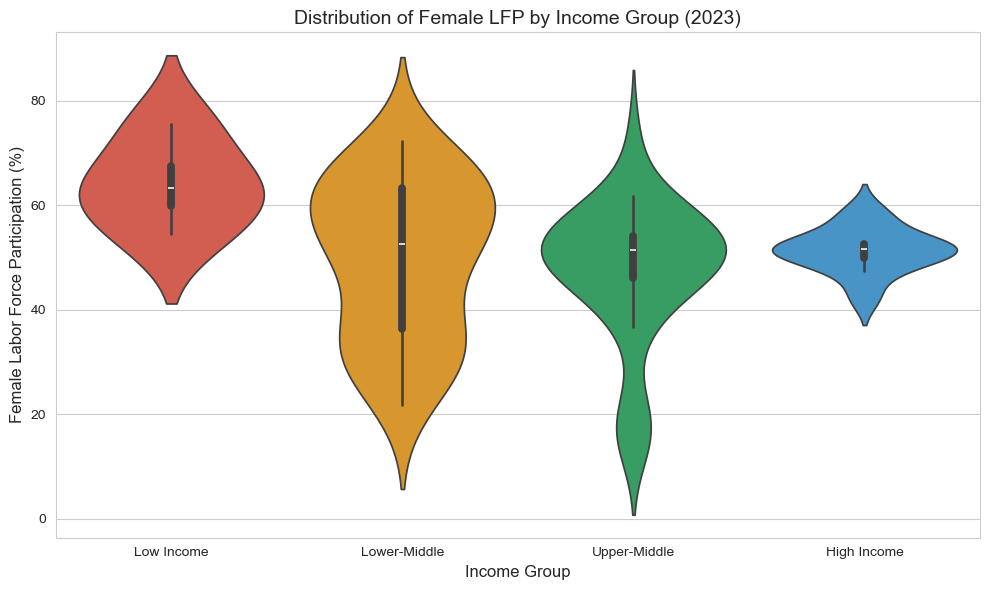

In [18]:
# Figure 4: Violin diagram
fig, ax = plt.subplots(figsize=(10, 6))
order = ['Low Income', 'Lower-Middle', 'Upper-Middle', 'High Income']
sns.violinplot(data=df_analysis, x='income_group', y='female_lfp', 
               hue='income_group', order=order, palette=colors, legend=False, ax=ax)
ax.set_xlabel('Income Group', fontsize=12)
ax.set_ylabel('Female Labor Force Participation (%)', fontsize=12)
ax.set_title('Distribution of Female LFP by Income Group (2023)', fontsize=14)
plt.tight_layout()
plt.savefig('lfp_violin.png', dpi=150)
plt.show()

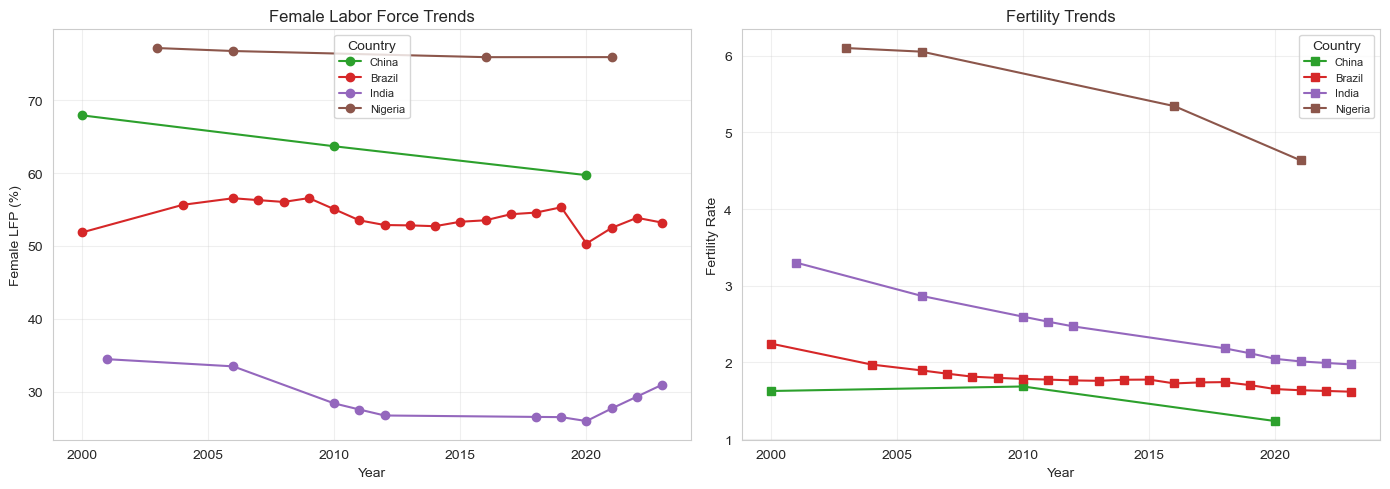

In [19]:
# Figure 5: Time Trend Chart
selected_countries = {
    'Sweden': '#1f77b4',
    'United States': '#ff7f0e',
    'China': '#2ca02c',
    'Brazil': '#d62728',
    'India': '#9467bd',
    'Nigeria': '#8c564b'
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for name, color in selected_countries.items():
    subset = df[df['Country Name'] == name].sort_values('Year')
    if len(subset) > 0:
        axes[0].plot(subset['Year'], subset['female_lfp'], 
                     marker='o', label=name, color=color, linewidth=1.5)
        axes[1].plot(subset['Year'], subset['fertility'], 
                     marker='s', label=name, color=color, linewidth=1.5)

axes[0].legend(title='Country', loc='best', fontsize=8)
axes[1].legend(title='Country', loc='best', fontsize=8)

axes[0].set_xlabel('Year')
axes[0].set_ylabel('Female LFP (%)')
axes[0].set_title('Female Labor Force Trends')
axes[0].grid(True, alpha=0.3)

axes[1].set_xlabel('Year')
axes[1].set_ylabel('Fertility Rate')
axes[1].set_title('Fertility Trends')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('time_trends.png', dpi=150)
plt.show()


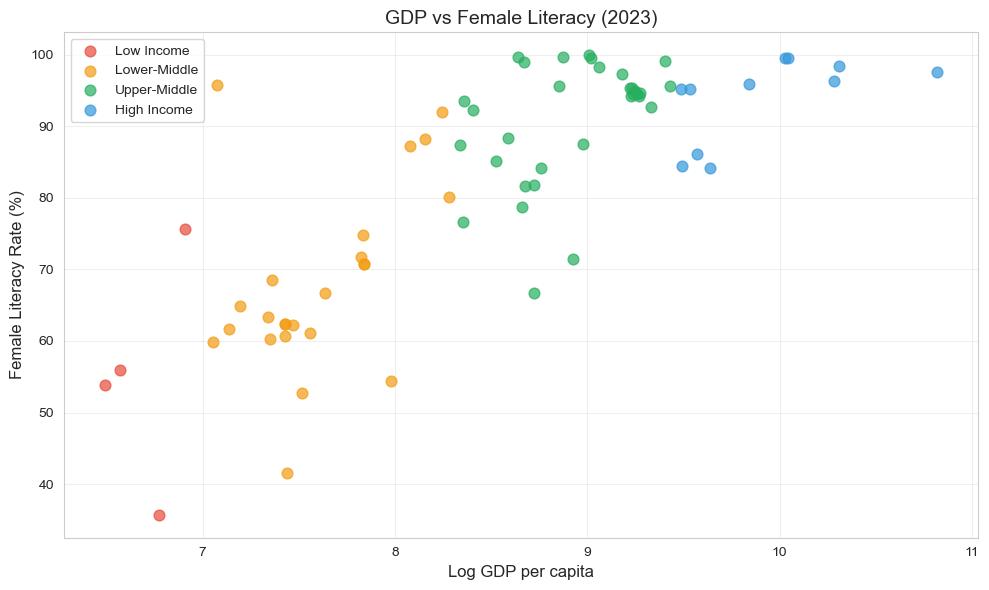

In [20]:
# Figure 6: GDP vs Female Literacy Rate
fig, ax = plt.subplots(figsize=(10, 6))
for group, color in colors.items():
    subset = df_analysis[df_analysis['income_group'] == group]
    ax.scatter(subset['log_gdp'], subset['female_literacy'], 
               c=color, label=group, alpha=0.7, s=60)
ax.set_xlabel('Log GDP per capita', fontsize=12)
ax.set_ylabel('Female Literacy Rate (%)', fontsize=12)
ax.set_title(f'GDP vs Female Literacy ({target_year})', fontsize=14)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('gdp_vs_literacy.png', dpi=150)
plt.show()

In [21]:
# Module 7: Statistical Output and Key Findings
# ============================================

# Correlation coefficient table - Fertility rate vs LFP
print("\n=== Correlation: Fertility vs Female LFP by Income Group ===")
for group in df_analysis['income_group'].unique():
    subset = df_analysis[df_analysis['income_group'] == group]
    if len(subset) > 3:
        corr = subset['fertility'].corr(subset['female_lfp'])
        print(f"{group:15s} (n={len(subset):3d}): r = {corr:.3f}")



=== Correlation: Fertility vs Female LFP by Income Group ===
Lower-Middle    (n= 24): r = 0.833
Upper-Middle    (n= 32): r = -0.427
High Income     (n= 11): r = -0.433
Low Income      (n=  4): r = -0.344


In [22]:
# Literacy rate vs LFP correlation coefficient (by income group)
print("\n=== Correlation: Literacy vs Female LFP by Income Group ===")
for group in df_analysis['income_group'].unique():
    subset = df_analysis[df_analysis['income_group'] == group]
    if len(subset) > 3:
        corr = subset['female_literacy'].corr(subset['female_lfp'])
        print(f"{group:15s} (n={len(subset):3d}): r = {corr:.3f}")


=== Correlation: Literacy vs Female LFP by Income Group ===
Lower-Middle    (n= 24): r = -0.603
Upper-Middle    (n= 32): r = 0.625
High Income     (n= 11): r = 0.124
Low Income      (n=  4): r = 0.505


In [23]:
# Statistical summary of each income group
print("\n=== Summary Statistics by Income Group (2023) ===")
summary = df_analysis.groupby('income_group')[['female_lfp', 'fertility', 'gdp_per_capita', 'female_literacy']].agg(['mean', 'count']).round(1)
print(summary)



=== Summary Statistics by Income Group (2023) ===
             female_lfp       fertility       gdp_per_capita        \
                   mean count      mean count           mean count   
income_group                                                         
High Income        51.3    11       1.7    11        22144.6    11   
Low Income         64.1     4       4.8     4          812.5     4   
Lower-Middle       49.5    24       3.5    24         2140.5    24   
Upper-Middle       47.3    32       2.0    32         7893.3    32   

             female_literacy        
                        mean count  
income_group                        
High Income             93.8    11  
Low Income              55.3     4  
Lower-Middle            68.1    24  
Upper-Middle            90.9    32  


In [24]:
# Top/Bottom 10
print("\n=== Top 10 Countries by Female LFP (2023) ===")
top_lfp = df_analysis.nlargest(10, 'female_lfp')[['Country Name', 'female_lfp', 'fertility', 'income_group', 'female_literacy']]
print(top_lfp.to_string(index=False))

print("\n=== Bottom 10 Countries by Female LFP (2023) ===")
bottom_lfp = df_analysis.nsmallest(10, 'female_lfp')[['Country Name', 'female_lfp', 'fertility', 'income_group', 'female_literacy']]
print(bottom_lfp.to_string(index=False))



=== Top 10 Countries by Female LFP (2023) ===
                              Country Name  female_lfp  fertility income_group  female_literacy
                                    Uganda   75.445000   4.283000   Low Income        75.580002
                                   Bolivia   72.455000   2.547000 Upper-Middle        93.500000
                                    Angola   72.318000   5.124000 Lower-Middle        54.369999
                Africa Western and Central   67.335124   4.497714 Lower-Middle        52.759998
Sub-Saharan Africa (excluding high income)   65.983464   4.372858 Lower-Middle        62.290001
                        Sub-Saharan Africa   65.128364   4.332478 Lower-Middle        62.299999
 Sub-Saharan Africa (IDA & IBRD countries)   65.128364   4.332478 Lower-Middle        62.299999
                              Burkina Faso   64.722000   4.186000   Low Income        35.731541
               Africa Eastern and Southern   63.592598   4.223861 Lower-Middle        68.

In [25]:
# Module 8: Summary of Key Findings
# ============================================
print("\n" + "="*50)
print("KEY FINDINGS SUMMARY")
print("="*50)

# 1.Overall relevance（GDP vs LFP）
overall_corr_gdp = df_analysis['log_gdp'].corr(df_analysis['female_lfp'])
print(f"\n1. GDP vs Female LFP Overall Correlation: r = {overall_corr_gdp:.3f}")
print("   → Economic development alone does NOT guarantee higher female employment.")



KEY FINDINGS SUMMARY

1. GDP vs Female LFP Overall Correlation: r = -0.110
   → Economic development alone does NOT guarantee higher female employment.


In [28]:
# 2. Overall correlation between literacy rate and LFP
overall_corr_literacy = df_analysis['female_literacy'].corr(df_analysis['female_lfp'])
print(f"\n2. Literacy vs Female LFP Overall Correlation: r = {overall_corr_literacy:.3f}")

if abs(overall_corr_literacy) > abs(overall_corr_gdp):
    print("   → Female literacy has a STRONGER correlation with LFP than GDP does.")
    print("   → Education matters more than economic growth for women's employment.")
else:
    print("   → GDP has a STRONGER correlation with LFP than literacy does.")


2. Literacy vs Female LFP Overall Correlation: r = -0.144
   → Female literacy has a STRONGER correlation with LFP than GDP does.
   → Education matters more than economic growth for women's employment.


In [29]:
# 3. U-shaped relationship
lfp_by_group = df_analysis.groupby('income_group')['female_lfp'].mean()
print(f"\n3. U-shaped Relationship:")
print(f"   Low Income: {lfp_by_group.get('Low Income', 0):.1f}%")
print(f"   Lower-Middle: {lfp_by_group.get('Lower-Middle', 0):.1f}%")
print(f"   Upper-Middle: {lfp_by_group.get('Upper-Middle', 0):.1f}%")
print(f"   High Income: {lfp_by_group.get('High Income', 0):.1f}%")

if lfp_by_group.get('Low Income', 0) > lfp_by_group.get('Upper-Middle', 0):
    print("   → U-shaped hypothesis SUPPORTED")



3. U-shaped Relationship:
   Low Income: 64.1%
   Lower-Middle: 49.5%
   Upper-Middle: 47.3%
   High Income: 51.3%
   → U-shaped hypothesis SUPPORTED


In [30]:
# 4. literacy rate by income group
lit_by_group = df_analysis.groupby('income_group')['female_literacy'].mean()
print(f"\n4. Female Literacy by Income Group:")
print(f"   Low Income: {lit_by_group.get('Low Income', 0):.1f}%")
print(f"   High Income: {lit_by_group.get('High Income', 0):.1f}%")
print(f"   → Gap: {lit_by_group.get('High Income', 0) - lit_by_group.get('Low Income', 0):.1f} percentage points")


4. Female Literacy by Income Group:
   Low Income: 55.3%
   High Income: 93.8%
   → Gap: 38.6 percentage points


In [31]:
# 5. extreme value
max_country = df_analysis.loc[df_analysis['female_lfp'].idxmax(), 'Country Name']
max_value = df_analysis['female_lfp'].max()
min_country = df_analysis.loc[df_analysis['female_lfp'].idxmin(), 'Country Name']
min_value = df_analysis['female_lfp'].min()
print(f"\n5. Female LFP Extremes:")
print(f"   Highest: {max_country} ({max_value:.0f}%)")
print(f"   Lowest: {min_country} ({min_value:.0f}%)")

print("\n" + "="*50)


5. Female LFP Extremes:
   Highest: Uganda (75%)
   Lowest: Iran, Islamic Rep. (14%)

